In [5]:
import pandas as pd
import numpy as np

In [6]:
# step 1: Loaded dataset from kaggle's csv to df 
df=pd.read_csv("student_study_habits.csv")

In [7]:
# Step 2: pre data-cleaning process,I. checking about the columns in dataset
df.columns 
# II. checking the information about columns 
df.info()
# III. checking if there are any null values in the respective dataset 
df.isnull().sum() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   study_hours_per_week            500 non-null    float64
 1   sleep_hours_per_day             500 non-null    float64
 2   attendance_percentage           500 non-null    float64
 3   assignments_completed           500 non-null    float64
 4   final_grade                     500 non-null    float64
 5   participation_level_Low         500 non-null    float64
 6   participation_level_Medium      500 non-null    float64
 7   internet_access_Yes             500 non-null    float64
 8   parental_education_High School  500 non-null    float64
 9   parental_education_Master's     500 non-null    float64
 10  parental_education_PhD          500 non-null    float64
 11  extracurricular_Yes             500 non-null    float64
 12  part_time_job_Yes               500 

study_hours_per_week              0
sleep_hours_per_day               0
attendance_percentage             0
assignments_completed             0
final_grade                       0
participation_level_Low           0
participation_level_Medium        0
internet_access_Yes               0
parental_education_High School    0
parental_education_Master's       0
parental_education_PhD            0
extracurricular_Yes               0
part_time_job_Yes                 0
dtype: int64

In [8]:
df.head()

,study_hours_per_week,sleep_hours_per_day,attendance_percentage,assignments_completed,final_grade,participation_level_Low,participation_level_Medium,internet_access_Yes,parental_education_High School,parental_education_Master's,parental_education_PhD,extracurricular_Yes,part_time_job_Yes
0,0.527230,0.685236,0.993245,0.222222,71.104897,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.421400,0.881883,0.883478,0.555556,62.240021,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.552393,0.220286,0.683469,1.000000,65.268855,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.698283,0.612594,0.520094,0.222222,66.609921,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.405419,0.369871,0.831127,0.333333,58.967484,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0


In [20]:
# step 3: Data cleaning 
# I. created a copy of data so original data doesn't gets changed when performing eda further 
df2=df.iloc[0:,0:].copy()

In [21]:
# II. Renaming the columns 
df2=df2.rename(columns={
    "study_hours_per_week":"study_hrs",
    "sleep_hours_per_day":"sleep_hrs",
    "attendance_percentage":"attendence",
    "assignments_completed":"assignments",
    "final_grade":"grade",
    "participation_level_Low":"part_low",
    "participation_level_Medium":"part_med",
    "internet_access_Yes":"net_yes",
    "parental_education_High School":"parent_hs",
    "parental_education_Master's":"parent_master",
    "parental_education_PhD":"parent_phd",
    "extracurricular_Yes":"extra_yes",
    "part_time_job_Yes":"job_yes"
})
df2.columns

Index(['study_hrs', 'sleep_hrs', 'attendence', 'assignments', 'grade',
       'part_low', 'part_med', 'net_yes', 'parent_hs', 'parent_master',
       'parent_phd', 'extra_yes', 'job_yes'],
      dtype='object')

In [22]:
df2.head()

,study_hrs,sleep_hrs,attendence,assignments,grade,part_low,part_med,net_yes,parent_hs,parent_master,parent_phd,extra_yes,job_yes
0,0.527230,0.685236,0.993245,0.222222,71.104897,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.421400,0.881883,0.883478,0.555556,62.240021,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.552393,0.220286,0.683469,1.000000,65.268855,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
3,0.698283,0.612594,0.520094,0.222222,66.609921,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.405419,0.369871,0.831127,0.333333,58.967484,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0


In [27]:
#III. To map the data to new values /replace the old values ( 1-YES and 0-NO )
df2["part_low"].unique()
df2["part_low"] = df2["part_low"].replace({0: "no", 1: "yes"})
df2["part_med"] = df2["part_med"].replace({0: "no", 1: "yes"}) 
df2["net_yes"] = df2["net_yes"].replace({0: "no", 1: "yes"})
df2["parent_hs"] = df2["parent_hs"].replace({0: "no", 1: "yes"})
df2["parent_master"] = df2["parent_master"].replace({0: "no", 1: "yes"})
df2["parent_phd"] = df2["parent_phd"].replace({0: "no", 1: "yes"})
df2["extra_yes"] = df2["extra_yes"].replace({0: "no", 1: "yes"})
df2["job_yes"] = df2["job_yes"].replace({0: "no", 1: "yes"})
df2

,study_hrs,sleep_hrs,attendence,assignments,grade,part_low,part_med,net_yes,parent_hs,parent_master,parent_phd,extra_yes,job_yes
0,0.527230,0.685236,0.993245,0.222222,71.104897,no,yes,yes,no,no,no,yes,no
1,0.421400,0.881883,0.883478,0.555556,62.240021,no,yes,yes,no,no,no,no,no
2,0.552393,0.220286,0.683469,1.000000,65.268855,no,yes,yes,no,no,no,yes,no
3,0.698283,0.612594,0.520094,0.222222,66.609921,yes,no,yes,no,no,no,yes,no
4,0.405419,0.369871,0.831127,0.333333,58.967484,no,yes,yes,yes,no,no,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.534263,0.443780,1.000000,0.222222,67.032033,no,yes,yes,yes,no,no,yes,no
496,0.271570,0.859537,1.000000,0.333333,57.419677,yes,no,yes,yes,no,no,no,no
497,0.412721,0.628169,0.949083,0.555556,74.950594,no,no,yes,yes,no,no,yes,no
498,0.298508,0.385764,0.906468,0.333333,55.271003,no,no,yes,yes,no,no,yes,no


In [30]:
# IV. Filtering data 
df2_new=df2.query("attendence>0.75 & grade>50")

,study_hrs,sleep_hrs,attendence,assignments,grade,part_low,part_med,net_yes,parent_hs,parent_master,parent_phd,extra_yes,job_yes
0,0.527230,0.685236,0.993245,0.222222,71.104897,no,yes,yes,no,no,no,yes,no
1,0.421400,0.881883,0.883478,0.555556,62.240021,no,yes,yes,no,no,no,no,no
4,0.405419,0.369871,0.831127,0.333333,58.967484,no,yes,yes,yes,no,no,yes,no
5,0.405422,0.402575,0.760664,0.555556,63.183453,no,no,no,no,no,yes,yes,yes
6,0.707647,0.381521,0.876671,0.888889,68.478048,no,yes,yes,no,yes,no,no,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.534263,0.443780,1.000000,0.222222,67.032033,no,yes,yes,yes,no,no,yes,no
496,0.271570,0.859537,1.000000,0.333333,57.419677,yes,no,yes,yes,no,no,no,no
497,0.412721,0.628169,0.949083,0.555556,74.950594,no,no,yes,yes,no,no,yes,no
498,0.298508,0.385764,0.906468,0.333333,55.271003,no,no,yes,yes,no,no,yes,no


In [34]:
# V. adding new columns 
# added column scholarship basis upon grade 
df2["Scholarship"] = df2["grade"].apply(
    lambda x: 1000 if 70 < x < 80 else (2000 if 80 < x < 90 else (3000 if 90 < x < 100 else (0)))
)

,study_hrs,sleep_hrs,attendence,assignments,grade,part_low,part_med,net_yes,parent_hs,parent_master,parent_phd,extra_yes,job_yes,Scholarship
0,0.527230,0.685236,0.993245,0.222222,71.104897,no,yes,yes,no,no,no,yes,no,1000
1,0.421400,0.881883,0.883478,0.555556,62.240021,no,yes,yes,no,no,no,no,no,0
2,0.552393,0.220286,0.683469,1.000000,65.268855,no,yes,yes,no,no,no,yes,no,0
3,0.698283,0.612594,0.520094,0.222222,66.609921,yes,no,yes,no,no,no,yes,no,0
4,0.405419,0.369871,0.831127,0.333333,58.967484,no,yes,yes,yes,no,no,yes,no,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.534263,0.443780,1.000000,0.222222,67.032033,no,yes,yes,yes,no,no,yes,no,0
496,0.271570,0.859537,1.000000,0.333333,57.419677,yes,no,yes,yes,no,no,no,no,0
497,0.412721,0.628169,0.949083,0.555556,74.950594,no,no,yes,yes,no,no,yes,no,1000
498,0.298508,0.385764,0.906468,0.333333,55.271003,no,no,yes,yes,no,no,yes,no,0


In [35]:
# step 4: Data visualization
import matplotlib.pyplot as plt 
import seaborn as sns  

Text(0.5, 0.98, 'Do High-Scoring Students Engage in Part-Time Jobs?')

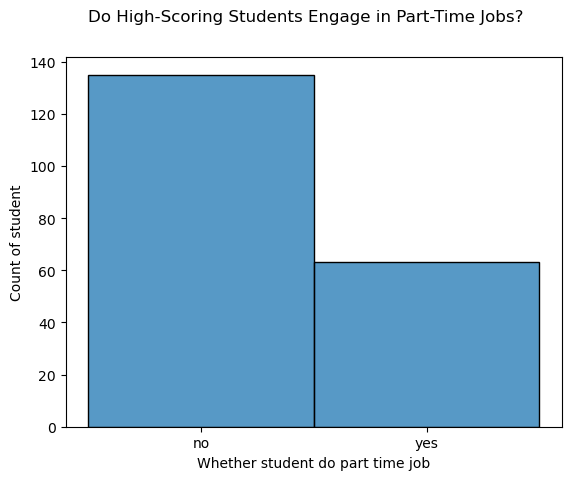

In [41]:
# I. how many students are doing part-time job and have also scored above 70 grade
fig,ax=plt.subplots()
sns.histplot(
    data=df2_new,
    x="job_yes",
    ax=ax
)
ax.set_xlabel("Whether student do part time job")
ax.set_ylabel("Count of student")
fig.suptitle("Do High-Scoring Students Engage in Part-Time Jobs?")

 # INSIGHT =  The histogram shows that several students who score above 70 are also involved in part-time jobs, 
 # indicating that employment does not necessarily hinder academic performance. 

Text(0.5, 0.98, 'Mean Student Grades by Parental Education (PhD vs Masters)')

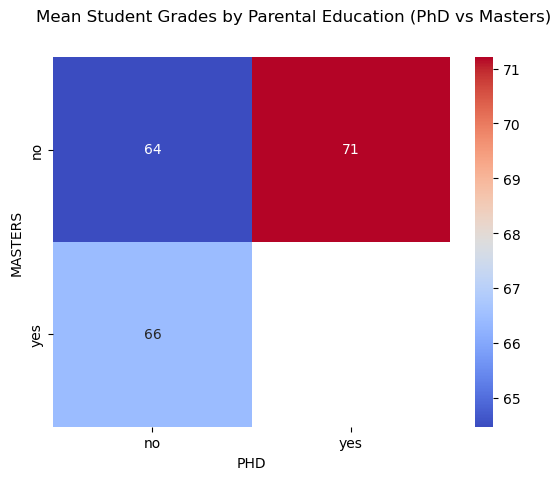

In [45]:
# II. do grades depend on parent's education ,i.e,do students who have parents with phd score more or 
# the ones whose parents have masters
df2_new1=df2_new.pivot_table(
    index="parent_master",
    columns="parent_phd",
    values="grade"
)
fig,ax=plt.subplots()
sns.heatmap(
    df2_new1,
    cmap="coolwarm",
    annot=True,
    ax=ax
)
ax.set_xlabel("PHD")
ax.set_ylabel("MASTERS")
fig.suptitle("Mean Student Grades by Parental Education (PhD vs Masters)")

# INSIGHTS = Students tend to score higher when at least one parent has a higher level of education (PhD or Master's),
# indicating a positive association between parental education and academic performance.

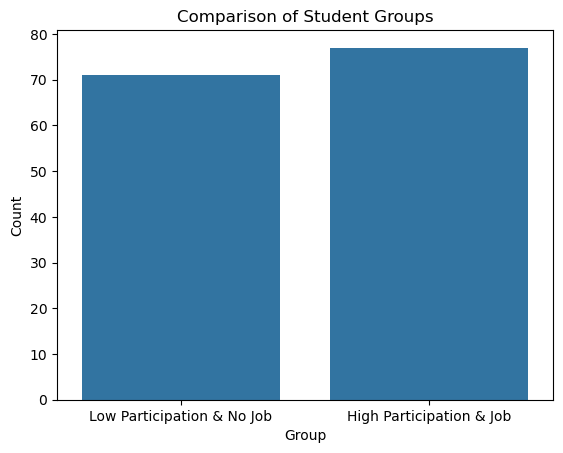

In [58]:
# III. How many students have low participation and also donot do any job vs 
# How many students participate as well as do job
filtered=df2.query("`part_low` == 'yes' & `job_yes` == 'no'")
filtered2=df2.query("`part_med` == 'yes' & `job_yes` == 'yes'")

count1=len(filtered)
count2=len(filtered2)

fig, ax = plt.subplots()

data = {
    "Group": ["Low Participation & No Job", "High Participation & Job"],
    "Count": [count1, count2]
}

sns.barplot(x="Group", y="Count", data=data)

plt.title("Comparison of Student Groups")
plt.show()

# INSIGHTS = From bargraph, This may indicate that students who are more engaged—both academically and through part-time work—are more common than 
# those with low involvement in both areas.

Text(0.5, 0.98, 'Attendence on basis of sleep and study hours')

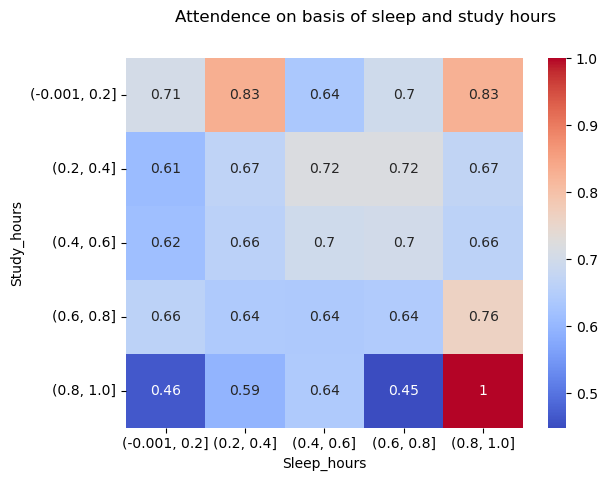

In [60]:
# IV. do study and sleep hours affect the attendence?
df2['study_bin'] = pd.cut(df2['study_hrs'], bins=5)
df2['sleep_bin'] = pd.cut(df2['sleep_hrs'], bins=5)

data=df2.pivot_table(
    index="study_bin",
    columns="sleep_bin",
    values="attendence",
    aggfunc="mean",
    observed=True
) 
fig,ax=plt.subplots()
sns.heatmap(
    data,
    cmap="coolwarm",
    annot=True,
    ax=ax
)
ax.set_xlabel("Sleep_hours")
ax.set_ylabel("Study_hours")
fig.suptitle("Attendence on basis of sleep and study hours")  

# INSIGHTS = The heatmap shows that the study and sleep hours are in normalised form (ranging from 0-1) and as the bins have been created then according to that 
# The heatmap suggests that student attendance is generally more consistent when both study hours and sleep hours fall
# within moderate ranges.
# Although the highest study and sleep hour combination shows perfect attendance, 
# this appears to be an outlier and may be influenced by a limited number of observations.

In [64]:
# step 5: sorting and saving the cleaned data file 
# added column scholarship basis upon grade 
df2_new["Scholarship"] = df2_new["grade"].apply(
    lambda x: 1000 if 70 < x < 80 else (2000 if 80 < x < 90 else (3000 if 90 < x < 100 else (0)))
)
# (on basis of grade)
df2_new=df2_new.sort_values("grade")
# (sorting the index)
df2_new=df2_new.reset_index(drop=True)
df2_new.to_csv("file1.csv")